# Coarse-to-fine non-rigid alignment example

This notebook demonstrates the complete workflow for large spatial omics slices:

1. Read paired `AnnData` slices.
2. Preprocess and compute shared latent features.
3. Build low-resolution voxel control points.
4. Run coarse rigid/similarity alignment on the low-resolution data.
5. Run non-rigid elastic registration on the low-resolution data.
6. Interpolate the learned nonlinear displacement field back to all source points.
7. Visualize the final stitching/alignment result.

In [1]:
import sys
from pathlib import Path

# Make GEASO importable when this notebook is launched from Tutorials/.
PROJECT_ROOT = Path(r"D:/st_projects/GEASO")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import torch
import anndata as ad
import matplotlib.pyplot as plt

plt.rcdefaults()

## 1. Read paired slices

The paths below are copied from `alignment_nonrigid.ipynb`. Here `slice2` is
treated as the moving/source slice and `slice1` as the fixed/target slice,
matching the earlier tutorial.

In [2]:
source_path = Path(r"E:/st_data/3D_rec/basic_usage_demo_2.h5ad")  # moving slice
target_path = Path(r"E:/st_data/3D_rec/basic_usage_demo_1.h5ad")  # fixed slice

slice2 = sc.read_h5ad(source_path)
slice1 = sc.read_h5ad(target_path)

section_ids = ["slice1", "slice2"]
slice1.obs["batch"] = section_ids[0]
slice2.obs["batch"] = section_ids[1]

slice1, slice2

(AnnData object with n_obs × n_vars = 17425 × 26137
     obs: 'area', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'louvain', 'cellbin_SpatialDomain', 'batch'
     uns: '__type', 'cellbin_SpatialDomain_colors', 'louvain', 'neighbors', 'pca', 'pearson_residuals_normalization', 'spatial'
     obsm: 'X_pca', 'X_spatial', 'bbox', 'spatial',
 AnnData object with n_obs × n_vars = 19939 × 26137
     obs: 'area', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'louvain', 'cellbin_SpatialDomain', 'batch'
     uns: '__type', 'cellbin_SpatialDomain_colors', 'louvain', 'neighbors', 'pca', 'pearson_residuals_normalization', 'spatial'
     obsm: 'X_pca', 'X_spatial', 'bbox', 'spatial')

## 2. Preprocess expression matrices

This keeps the same preprocessing style as the original notebook. The raw
counts are saved in `layers['counts']`, then normalized/log-transformed
expression is used for downstream feature extraction.

In [3]:
def preprocess_slice(adata):
    adata.var_names_make_unique()
    sc.pp.filter_cells(adata, min_genes=10)
    sc.pp.filter_genes(adata, min_cells=3)
    adata.layers["counts"] = adata.X.copy()
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=2000)
    return adata


slice1 = preprocess_slice(slice1)
slice2 = preprocess_slice(slice2)

from GEASO.utils.utils import intersect

common_genes = intersect(slice1.var_names, slice2.var_names)
slice1 = slice1[:, common_genes].copy()
slice2 = slice2[:, common_genes].copy()

slice1.shape, slice2.shape

((17425, 18741), (19939, 18741))

## 3. Compute or load latent representations

`coarse_to_fine_alignment(...)` can use `obsm['latent']` for expression
similarity. If you already have latent features, load them into
`slice1.obsm['latent']` and `slice2.obsm['latent']` before running the
alignment.

The block below reproduces the original tutorial's `feature_extract(...)`
call.

Training on cuda, please wait...


Epoch: 199, Loss: -439.831 step time=0.211s: 100%|██████████| 200/200 [00:42<00:00,  4.66it/s]


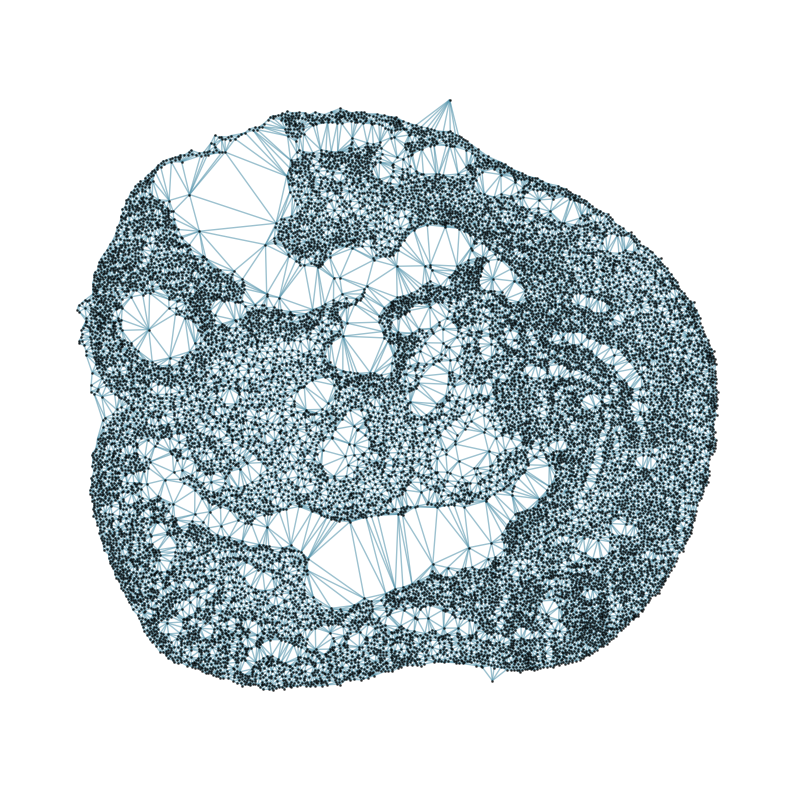

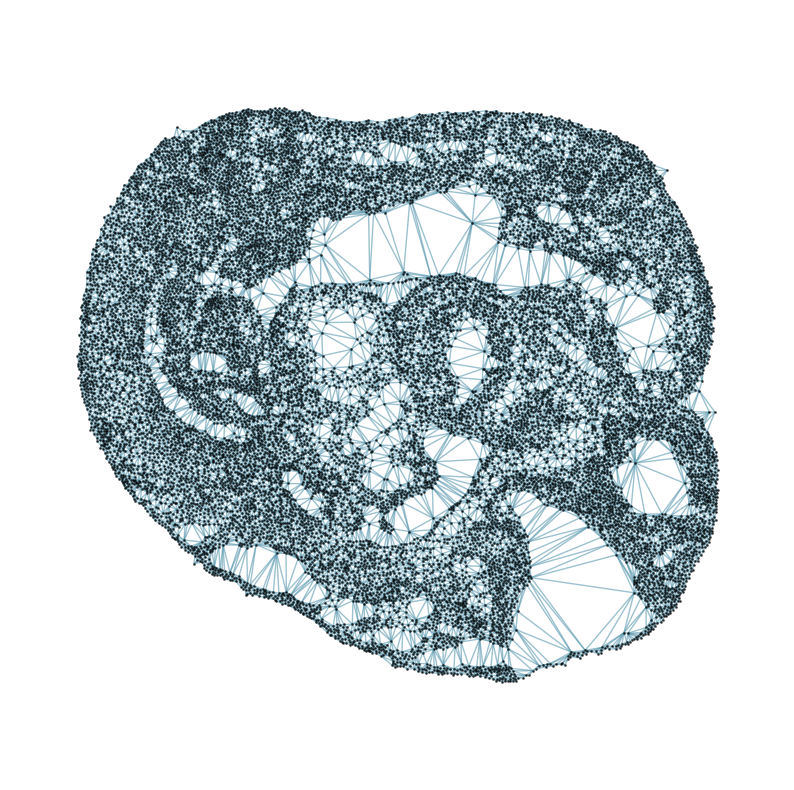

In [4]:
from GEASO.utils.utils import feature_extract

adata_list = [slice1, slice2]
emb_dict, loss_log, model = feature_extract(adata_list)

slice1.obsm["latent"] = emb_dict[section_ids[0]].detach().cpu().numpy()
slice2.obsm["latent"] = emb_dict[section_ids[1]].detach().cpu().numpy()

torch.cuda.empty_cache()

## 4. Full coarse-to-fine alignment in one call

This is the recommended API for large slices. Internally it will:

- voxelize source and target into low-resolution control points;
- run `coarse_alignment(...)` on those control points;
- run `ElasticRegistration(...)` on those control points;
- compute low-resolution displacement vectors;
- interpolate the displacement field back to every source spot/cell.

The returned `info` dictionary keeps the low-resolution objects and
displacement vectors for inspection.

In [5]:
from GEASO.alignment import coarse_to_fine_alignment

# Tune these according to slice size. Larger values preserve more local detail;
# smaller values are faster and use less memory.
SOURCE_VOXEL_NUM = 5000
TARGET_VOXEL_NUM = 5000

# slice2 is the moving/source slice; slice1 is the fixed/target slice.
info = coarse_to_fine_alignment(
    source=slice2,
    target=slice1,
    spatial_key="spatial",
    rep_layer="latent",
    rep_field="obsm",
    source_voxel_num=SOURCE_VOXEL_NUM,
    target_voxel_num=TARGET_VOXEL_NUM,
    top_K=10,
    dis_metric="cos",
    use_latent=True,
    scale_c=False,
    spatial_add="aligned_spatial_nonrigid",
    rigid_add="aligned_spatial_rigid",
    coarse_add="spatial_coarse",
    interpolation_method="knn",
    interpolation_k=32,
    interpolation_chunk_size=50000,
    max_iter=500,
    non_rigid_start_iter=80,
    K=100,
    graph_knn=10,
    tau=0.5,
    lambda_VF=1e1,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    verbose=True,
    inplace=True,
    return_info=True,
)

# Keep the target slice in the same final coordinate fields for concatenated visualization.
slice1.obsm["spatial_coarse"] = slice1.obsm["spatial"].copy()
slice1.obsm["aligned_spatial_rigid"] = slice1.obsm["spatial"].copy()
slice1.obsm["aligned_spatial_nonrigid"] = slice1.obsm["spatial"].copy()

info.keys()

Local structure kernel constructed with shape: torch.Size([3448, 100])


Slice Alignment: 100%|██████████| 500/500 [00:03<00:00, 126.75it/s]


dict_keys(['source', 'target', 'low_source', 'low_target', 'registration', 'scales', 'means', 'R', 't', 'scale', 'control_points', 'control_displacements', 'full_displacements'])

## 5. Inspect the intermediate downsampled control points

These are the points on which the expensive rigid/non-rigid optimization
was actually performed.

In [6]:
low_source = info["low_source"]
low_target = info["low_target"]

print("original source:", slice2.n_obs)
print("original target:", slice1.n_obs)
print("low-resolution source:", low_source.n_obs)
print("low-resolution target:", low_target.n_obs)

low_source.obsm.keys(), low_target.obsm.keys()

original source: 19939
original target: 17425
low-resolution source: 3448
low-resolution target: 3257


(KeysView(AxisArrays with keys: spatial, latent, spatial_coarse, aligned_spatial_rigid, aligned_spatial_nonrigid),
 KeysView(AxisArrays with keys: spatial, latent, spatial_coarse))

In [12]:
low_target.obsm["spatial_coarse"] = low_target.obsm["spatial"].copy()
low_target.obsm["aligned_spatial_rigid"] = low_target.obsm["spatial"].copy()
low_target.obsm["aligned_spatial_nonrigid"] = low_target.obsm["spatial"].copy()

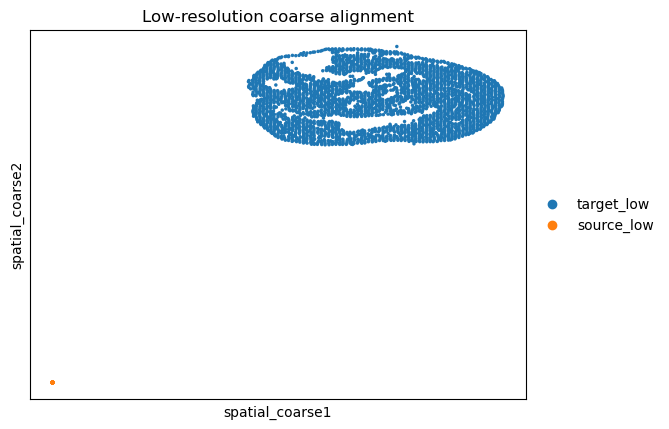

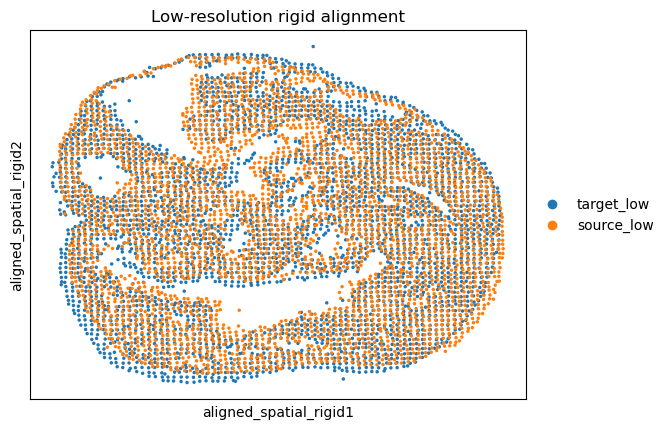

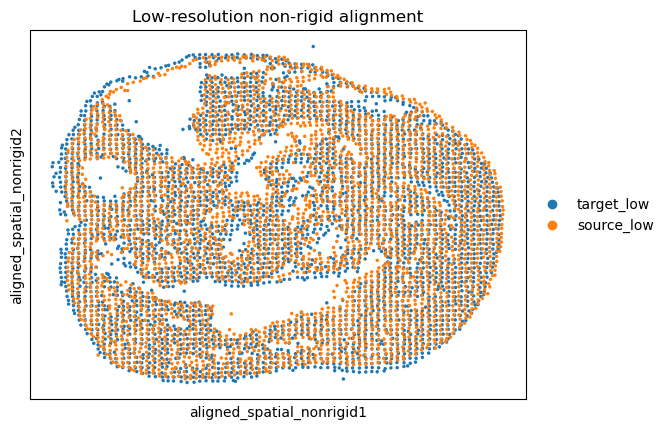

In [13]:
low_source.obs["batch"] = "source_low"
low_target.obs["batch"] = "target_low"

low_cat = ad.concat([low_target, low_source], label="batch", keys=["target_low", "source_low"])

sc.pl.embedding(low_cat, basis="spatial_coarse", color="batch", size=25, title="Low-resolution coarse alignment")
sc.pl.embedding(low_cat, basis="aligned_spatial_rigid", color="batch", size=25, title="Low-resolution rigid alignment")
sc.pl.embedding(low_cat, basis="aligned_spatial_nonrigid", color="batch", size=25, title="Low-resolution non-rigid alignment")

## 6. Inspect nonlinear displacement vectors

The control displacement is defined as:

```python
low_source.obsm['aligned_spatial_nonrigid'] - low_source.obsm['aligned_spatial_rigid']
```

Then `interpolate_displacement_field(...)` spreads this sparse vector
field back to all source coordinates.

In [14]:
control_points = info["control_points"]
control_displacements = info["control_displacements"]
full_displacements = info["full_displacements"]

print("control_points:", control_points.shape)
print("control_displacements:", control_displacements.shape)
print("full_displacements:", full_displacements.shape)
print("mean full displacement norm:", np.linalg.norm(full_displacements, axis=1).mean())

control_points: (3448, 2)
control_displacements: (3448, 2)
full_displacements: (19939, 2)
mean full displacement norm: 72.42410469865777


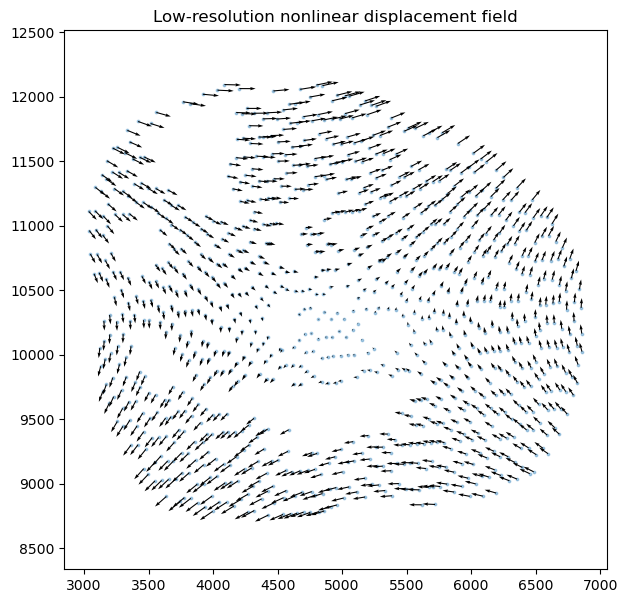

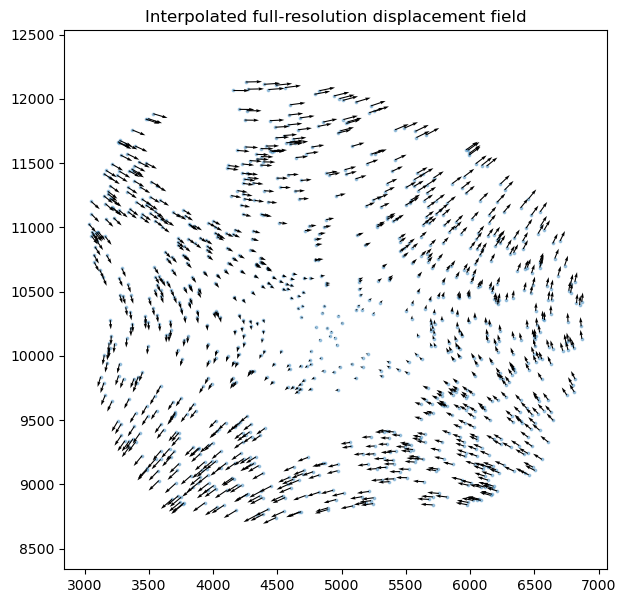

In [15]:
def plot_displacement_vectors(points, vectors, title, max_vectors=1000, scale=1.0):
    if points.shape[0] > max_vectors:
        idx = np.linspace(0, points.shape[0] - 1, max_vectors, dtype=int)
        points = points[idx]
        vectors = vectors[idx]

    plt.figure(figsize=(7, 7))
    plt.scatter(points[:, 0], points[:, 1], s=3, alpha=0.35)
    plt.quiver(
        points[:, 0], points[:, 1],
        vectors[:, 0], vectors[:, 1],
        angles="xy", scale_units="xy", scale=scale, width=0.002,
    )
    plt.title(title)
    plt.axis("equal")
    plt.show()


plot_displacement_vectors(control_points, control_displacements, "Low-resolution nonlinear displacement field")
plot_displacement_vectors(slice2.obsm["aligned_spatial_rigid"], full_displacements, "Interpolated full-resolution displacement field")

## 7. Visualize raw, coarse, rigid, and final non-rigid alignment

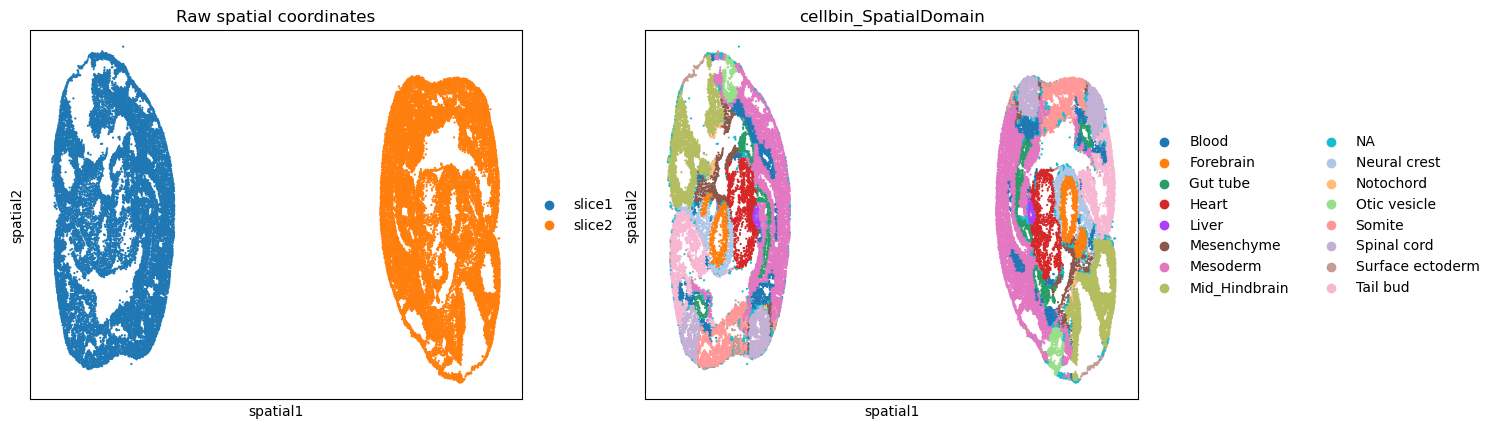

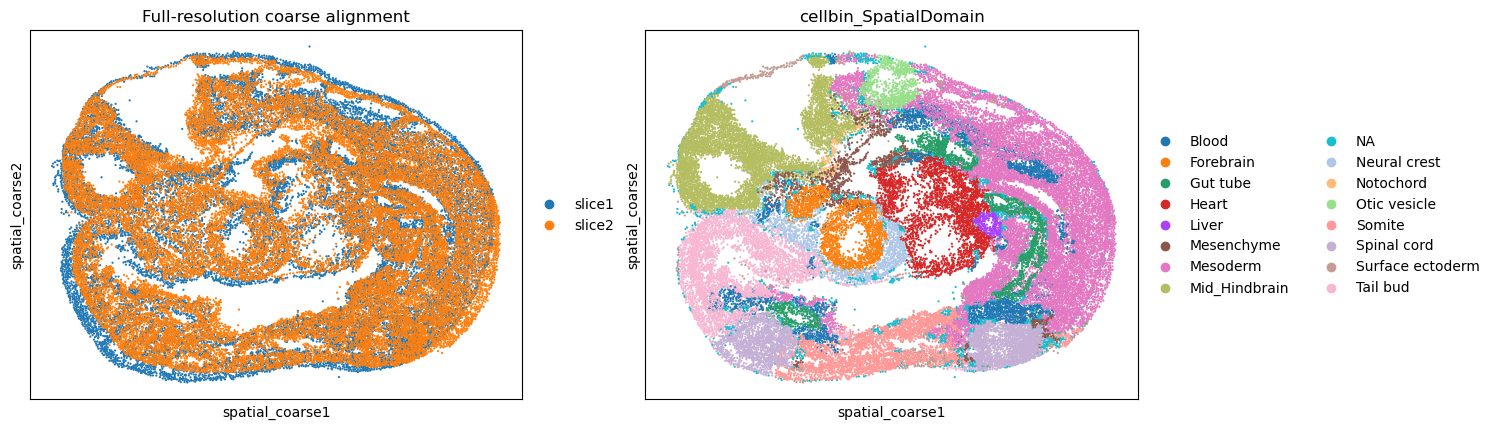

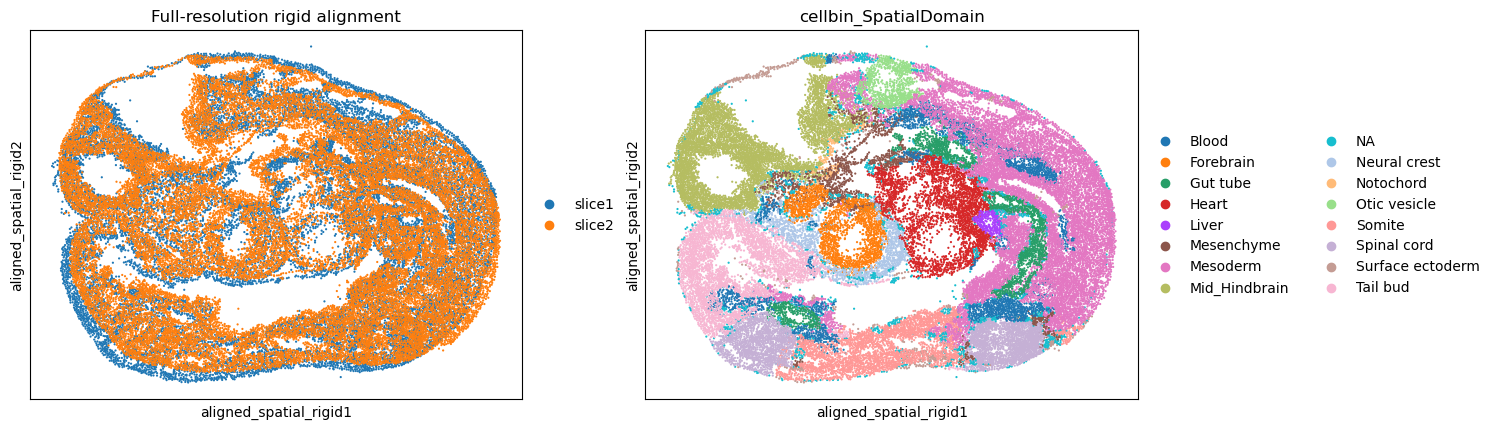

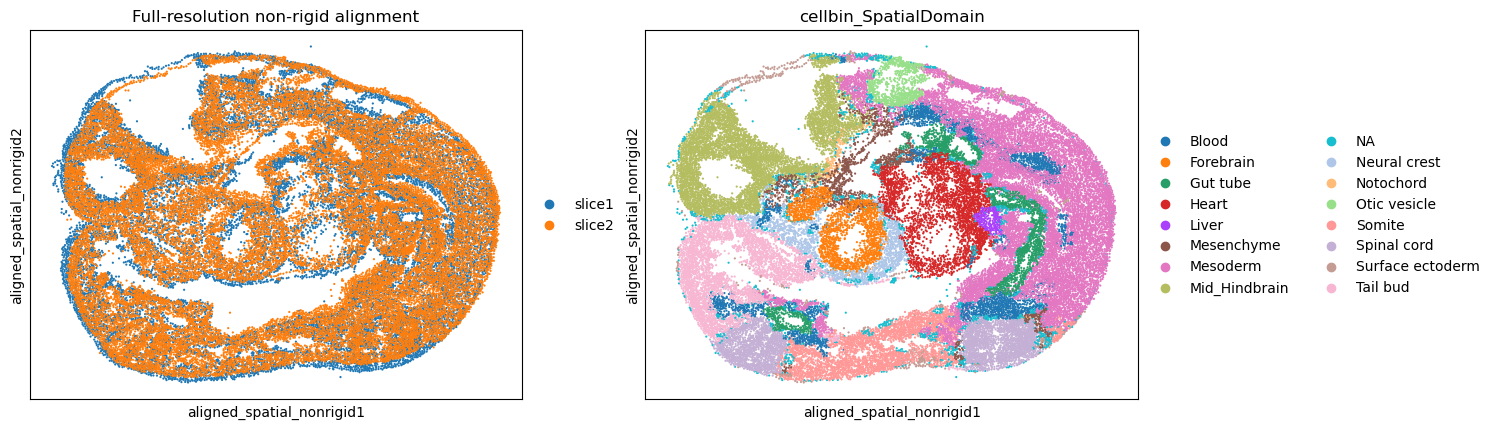

In [16]:
adata_cat = ad.concat([slice1, slice2], label="batch", keys=["slice1", "slice2"])

color_keys = ["batch"]
if "cellbin_SpatialDomain" in adata_cat.obs:
    color_keys.append("cellbin_SpatialDomain")

sc.pl.embedding(adata_cat, basis="spatial", color=color_keys, size=10, title="Raw spatial coordinates")
sc.pl.embedding(adata_cat, basis="spatial_coarse", color=color_keys, size=10, title="Full-resolution coarse alignment")
sc.pl.embedding(adata_cat, basis="aligned_spatial_rigid", color=color_keys, size=10, title="Full-resolution rigid alignment")
sc.pl.embedding(adata_cat, basis="aligned_spatial_nonrigid", color=color_keys, size=10, title="Full-resolution non-rigid alignment")

## 8. Optional: manually rerun only the interpolation step

Use this when you want to test different interpolation hyperparameters
without repeating the expensive low-resolution registration.

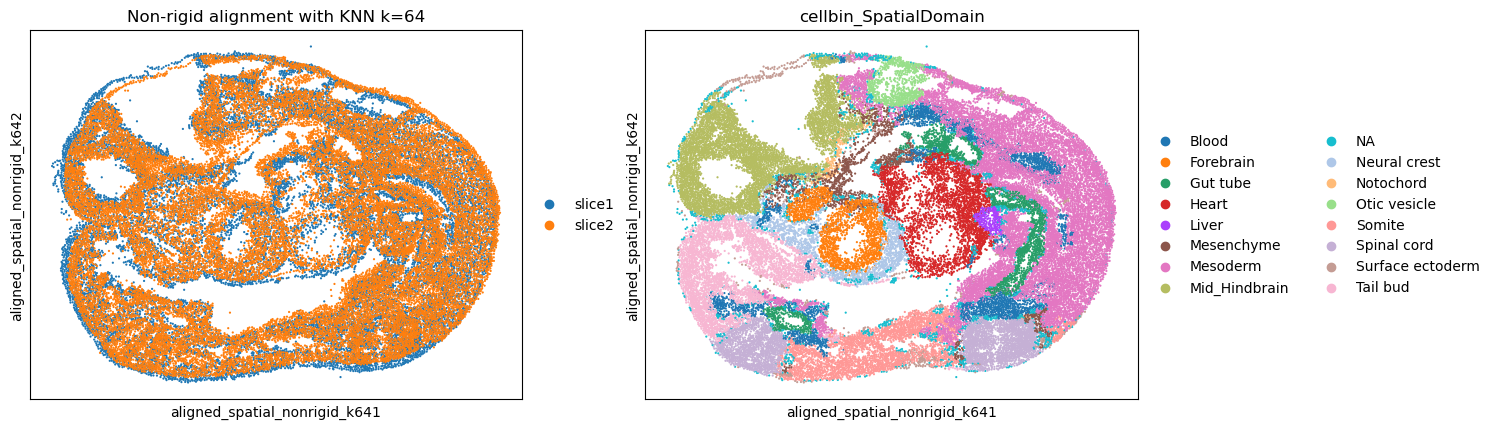

In [17]:
from GEASO.alignment import interpolate_displacement_field

full_displacements_k64 = interpolate_displacement_field(
    control_points=info["control_points"],
    control_displacements=info["control_displacements"],
    query_points=slice2.obsm["aligned_spatial_rigid"],
    method="knn",
    k=64,
    bandwidth=None,
    chunk_size=50000,
)

slice2.obsm["aligned_spatial_nonrigid_k64"] = slice2.obsm["aligned_spatial_rigid"] + full_displacements_k64
slice1.obsm["aligned_spatial_nonrigid_k64"] = slice1.obsm["spatial"].copy()

adata_cat_k64 = ad.concat([slice1, slice2], label="batch", keys=["slice1", "slice2"])
sc.pl.embedding(adata_cat_k64, basis="aligned_spatial_nonrigid_k64", color=color_keys, size=10, title="Non-rigid alignment with KNN k=64")

## 9. Optional: build nearest-neighbor matching for 3D visualization

This mirrors the tail of the original notebook.

In [18]:
from sklearn.neighbors import BallTree

adata1_harm_df = pd.DataFrame({
    "index": range(slice1.shape[0]),
    "x": slice1.obsm["aligned_spatial_nonrigid"][:, 0],
    "y": slice1.obsm["aligned_spatial_nonrigid"][:, 1],
})
adata2_harm_df = pd.DataFrame({
    "index": range(slice2.shape[0]),
    "x": slice2.obsm["aligned_spatial_nonrigid"][:, 0],
    "y": slice2.obsm["aligned_spatial_nonrigid"][:, 1],
})

if "cellbin_SpatialDomain" in slice1.obs:
    adata1_harm_df["domain"] = slice1.obs["cellbin_SpatialDomain"].astype("category").to_numpy()
    adata2_harm_df["domain"] = slice2.obs["cellbin_SpatialDomain"].astype("category").to_numpy()
else:
    adata1_harm_df["domain"] = "slice1"
    adata2_harm_df["domain"] = "slice2"


def build_nearest_mapping(coords_source, coords_target):
    tree = BallTree(coords_target, leaf_size=15)
    _, nn_idx = tree.query(coords_source, k=1)
    source_idx = np.arange(coords_source.shape[0])
    target_idx = nn_idx[:, 0]
    return np.array([source_idx, target_idx])


matching_harm = build_nearest_mapping(
    slice2.obsm["aligned_spatial_nonrigid"],
    slice1.obsm["aligned_spatial_nonrigid"],
)

matching_harm.shape

(2, 19939)

dataset1: 16 cell types; dataset2: 16 cell types; 
                    Total :16 celltypes; Overlap: 16 cell types 
                    Not overlap :[[]]
Subsampled 200 pairs from 19939


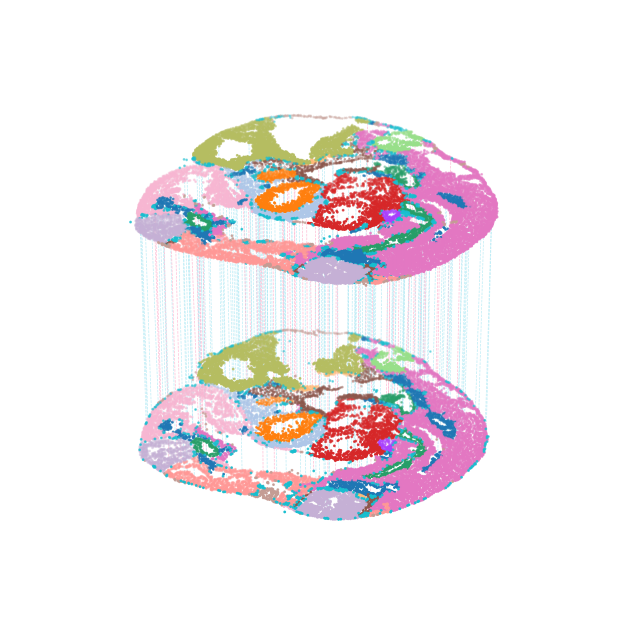

In [19]:
from GEASO.plot_utils.visualize import Build3D

multi_align = Build3D(
    adata1_harm_df,
    adata2_harm_df,
    matching_harm,
    meta="domain",
    scale_coordinate=False,
    subsample_size=200,
    exchange_xy=False,
)
multi_align.draw_3D(
    size=[16, 8],
    line_width=0.5,
    point_size=[1, 1],
    hide_axis=True,
    show_error=True,
    line_alpha=0.8,
)